# Lesson 18B: Kernel Density Estimation — Practice

## Introduction

Lesson 18A established that KDE has exactly one parameter worth arguing about and derived where its optimum comes from. This notebook spends that theory on four jobs a density estimate actually does, and then on the job it cannot do.

The through-line is that **a density is not only something you plot**. Once you have $\hat f$, you can *sample* from it — which turns a density estimator into a generative model, and lets us reproduce scikit-learn's digit-generation example and explain why it works. You can *threshold* it — which turns it into an anomaly detector, directly comparable with the Isolation Forest and LOF of Lesson 7 on the same data and the same metric. You can *contour* it — which turns clustering output into something you can read.

And then there is the fourth thing, which is where this lesson earns its keep: you can watch it stop working. Lesson 18A predicted from the AMISE rate that KDE degrades as dimension grows. Section 8 sets out to confirm that on a real decision — and the first experiment fails to, because it was built with a confound in it. Rather than quietly replacing it, the notebook reports the failed version, names the confound, and then runs the controlled experiment that does isolate dimension. Knowing the failure boundary of a tool is worth more than another success story, and knowing how easily an experiment can miss that boundary is worth more still.

In this lesson:
1. `KernelDensity` with the bandwidth chosen by `GridSearchCV`, cross-checked against `scipy.stats.gaussian_kde` and against Lesson 18A's from-scratch estimator
2. Sampling: PCA + KDE as a generative model for handwritten digits
3. Anomaly detection: log-density thresholding against Isolation Forest and LOF, scored by PR-AUC
4. Visualisation: 2-D density contours over clustering output
5. The failure case: where in dimension the density scores stop discriminating, measured

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [KernelDensity, Cross-Validated](#kernel-density)
4. [Sampling: PCA + KDE as a Generative Model](#sampling)
5. [Density-Based Anomaly Detection](#anomaly)
6. [Density Contours over Clustering Output](#contours)
7. [Where KDE Breaks: Dimension](#breaks)
8. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.neighbors import KernelDensity, LocalOutlierFactor, NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import load_digits, load_iris
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

digits = load_digits()
print(f"digits: {digits.data.shape[0]} samples x {digits.data.shape[1]} features, "
      f"{len(np.unique(digits.target))} classes")
print("All data is bundled with scikit-learn — nothing is downloaded.")

digits: 1797 samples x 64 features, 10 classes
All data is bundled with scikit-learn — nothing is downloaded.


<a name="kernel-density"></a>
## KernelDensity, Cross-Validated

Lesson 18A implemented leave-one-out CV by hand to make the criterion visible. In practice you hand the same idea to `GridSearchCV`, because `KernelDensity.score()` already returns the **total log-likelihood** of the data passed to it — so cross-validating that score is exactly the LOO argument generalised to $k$ folds:

$$\text{CV}_k(h) = \sum_{j=1}^{k} \sum_{i \in \text{fold}_j} \log \hat f_{-\text{fold}_j}(x_i).$$

The held-out fold plays the role the omitted point played in Section 6 of 18A, and for the same reason: score a point under a density that used it, and the criterion is maximised by $h \to 0$.

Three implementations get compared here, and the comparison is arranged so a mistake would show rather than hide:

- the **from-scratch** estimator from Lesson 18A, reproduced below (these notebooks stand alone, so nothing is imported across them)
- **`KernelDensity`**, whose `bandwidth` is an absolute bandwidth in data units
- **`scipy.stats.gaussian_kde`**, whose `bw_method` is a *multiplier on the sample standard deviation*, not a bandwidth

That last difference is the trap Lesson 18A flagged: pass the same number to both and you get two different estimates that look plausible. The conversion is done explicitly below and the check is on maximum absolute deviation, not on an eyeballed overlay.

GridSearchCV over 40 bandwidths, 5-fold, scoring = total held-out log-likelihood
  selected bandwidth h = 8.821
  mean CV score at h   = -1244.710
  held-out log-lik/pt  = -4.9148

comparison                             max |diff|   agree
---------------------------------------------------------
from-scratch (18A) vs sklearn            6.23e-16    True
from-scratch (18A) vs scipy              4.86e-17    True
sklearn vs scipy                         6.35e-16    True

If h were passed to scipy's bw_method unconverted:
  max |diff| vs the correct curve = 0.0088   (the correct curve peaks at 0.0101)
  Same order of magnitude as the density itself — a silent, plausible-looking error.


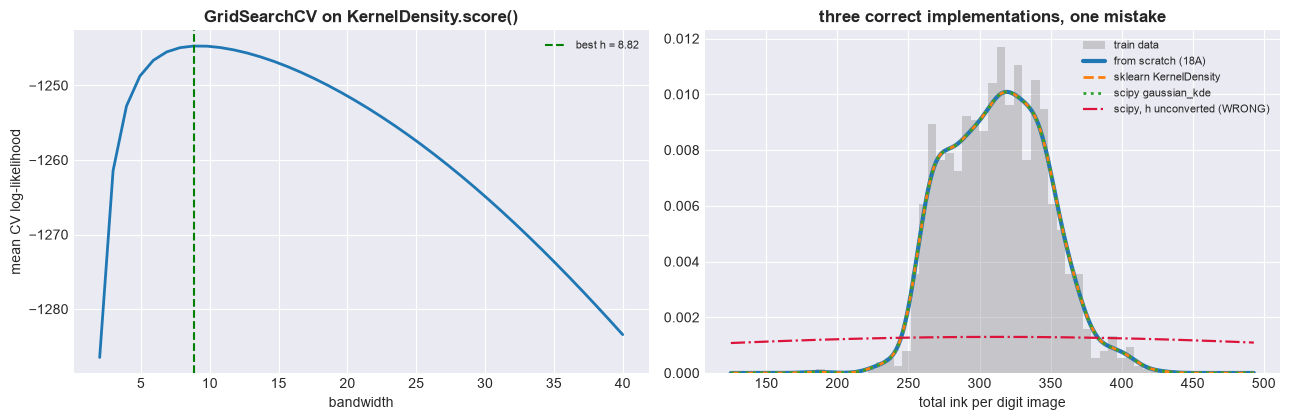

In [2]:
# Lesson 18A's from-scratch estimator, reproduced so this notebook stands alone.
def kde_scratch(x_eval, data, h):
    # (n_eval, n_data) scaled distances -> gaussian kernel -> mean, divided by h.
    u = (np.asarray(x_eval)[:, None] - np.asarray(data)[None, :]) / h
    return np.exp(-0.5 * u ** 2).sum(axis=1) / (len(data) * h * np.sqrt(2 * np.pi))


# A 1-D quantity with real structure: the total ink in each digit image.
ink = digits.data.sum(axis=1).astype(float)
ink_train, ink_test = train_test_split(ink, test_size=0.3, random_state=0)

grid_h = {'bandwidth': np.linspace(2.0, 40.0, 40)}
gs = GridSearchCV(KernelDensity(kernel='gaussian'), grid_h, cv=5)
gs.fit(ink_train[:, None])
h_cv = gs.best_params_['bandwidth']

print(f"GridSearchCV over {len(grid_h['bandwidth'])} bandwidths, 5-fold, "
      f"scoring = total held-out log-likelihood")
print(f"  selected bandwidth h = {h_cv:.3f}")
print(f"  mean CV score at h   = {gs.best_score_:.3f}")
print(f"  held-out log-lik/pt  = {gs.best_estimator_.score(ink_test[:, None]) / len(ink_test):.4f}")

xs = np.linspace(ink.min() - 60, ink.max() + 60, 400)
mine = kde_scratch(xs, ink_train, h_cv)
skl = np.exp(gs.best_estimator_.score_samples(xs[:, None]))
# scipy's bw_method multiplies the sample std, so convert the absolute h into that factor.
sp = stats.gaussian_kde(ink_train, bw_method=h_cv / np.std(ink_train, ddof=1))(xs)

print(f"\n{'comparison':<36}{'max |diff|':>13}{'agree':>8}")
print('-' * 57)
for lab, a, b in [('from-scratch (18A) vs sklearn', mine, skl),
                  ('from-scratch (18A) vs scipy', mine, sp),
                  ('sklearn vs scipy', skl, sp)]:
    d = float(np.max(np.abs(a - b)))
    print(f"{lab:<36}{d:>13.2e}{str(d < 1e-9):>8}")

# What the trap would have cost: pass h straight to scipy as if it were a bandwidth.
sp_wrong = stats.gaussian_kde(ink_train, bw_method=h_cv)(xs)
print(f"\nIf h were passed to scipy's bw_method unconverted:")
print(f"  max |diff| vs the correct curve = {np.max(np.abs(sp_wrong - skl)):.4f}"
      f"   (the correct curve peaks at {skl.max():.4f})")
print("  Same order of magnitude as the density itself — a silent, plausible-looking error.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(gs.cv_results_['param_bandwidth'].data.astype(float),
             gs.cv_results_['mean_test_score'], lw=2)
axes[0].axvline(h_cv, color='green', ls='--', label=f'best h = {h_cv:.2f}')
axes[0].set_xlabel('bandwidth'); axes[0].set_ylabel('mean CV log-likelihood')
axes[0].set_title('GridSearchCV on KernelDensity.score()', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].hist(ink_train, bins=40, density=True, alpha=0.35, color='grey', label='train data')
axes[1].plot(xs, mine, lw=3, label='from scratch (18A)')
axes[1].plot(xs, skl, '--', lw=2, label='sklearn KernelDensity')
axes[1].plot(xs, sp, ':', lw=2, label='scipy gaussian_kde')
axes[1].plot(xs, sp_wrong, '-.', lw=1.6, color='crimson', label='scipy, h unconverted (WRONG)')
axes[1].set_xlabel('total ink per digit image')
axes[1].set_title('three correct implementations, one mistake', fontweight='bold')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

<a name="sampling"></a>
## Sampling: PCA + KDE as a Generative Model

A density estimate you can *draw from* is a generative model. `KernelDensity.sample()` makes this almost trivial, because sampling a KDE needs no machinery at all: pick one of the $n$ training points uniformly, then draw from the kernel centred on it. That is the whole algorithm, and it follows directly from the estimator's definition as an equal mixture of $n$ kernels.

$$\hat f(\mathbf{x}) = \frac{1}{n}\sum_{i=1}^{n} K_h(\mathbf{x} - \mathbf{X}_i)
\quad\Longrightarrow\quad
\text{sample: } i \sim \text{Uniform}\{1..n\},\; \mathbf{x} = \mathbf{X}_i + h\boldsymbol{\varepsilon}.$$

The catch is Lesson 18A's Section 8. A digit image is 64-dimensional, and KDE at $d=64$ is hopeless — the estimate would be a set of 1,797 isolated spikes with nothing in between, and sampling it would return training images plus noise.

The fix is the standard one and it is why this example is built the way it is: **reduce first, estimate second**. PCA to 15 components (Lesson 5) puts the data somewhere KDE can work, the KDE is fitted there, samples are drawn there, and `inverse_transform` lifts them back to pixel space. The generative model is the *composition* — neither part would work alone.

Below, the bandwidth is again chosen by cross-validation rather than picked, and the generated digits are shown beside real ones. The honest check is not whether they look like digits; it is whether they are **new** — a KDE with a tiny bandwidth would memorise, so the notebook measures the distance from each sample to its nearest training image.

PCA: 64 -> 15 dimensions, retaining 83.5% of the variance


cross-validated bandwidth in the 15-D PCA space: h = 3.6169

Distance to the nearest TRAINING image (pixel space, Euclidean):
  generated samples : median   18.68   min   12.36
  real images       : median   16.12   min    5.29
  ratio of medians  : 1.16

Generated samples sit farther from the training set than real images sit from each
other -- a modest 16% gap in the medians (18.68 vs 16.12). The minimum distances make the same point far more strongly (12.36 vs 5.29, a 2.3x gap): even the CLOSEST generated sample sits well outside the closest real-to-real pair. So the model is not returning memorised digits with a little noise added.
That is the bandwidth doing its job: large enough to interpolate between examples.


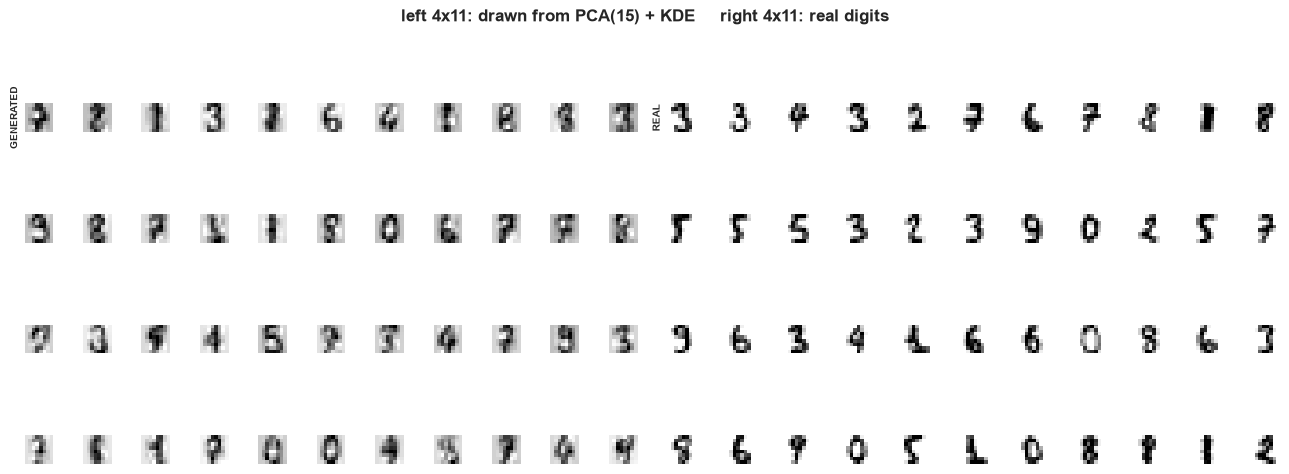

In [3]:
pca = PCA(n_components=15, whiten=False, random_state=0)
Z = pca.fit_transform(digits.data)
print(f"PCA: 64 -> 15 dimensions, retaining "
      f"{pca.explained_variance_ratio_.sum():.1%} of the variance")

gs_d = GridSearchCV(KernelDensity(kernel='gaussian'),
                    {'bandwidth': np.logspace(-1, 1.2, 25)}, cv=5)
gs_d.fit(Z)
kde_gen = gs_d.best_estimator_
print(f"cross-validated bandwidth in the 15-D PCA space: h = "
      f"{gs_d.best_params_['bandwidth']:.4f}")

n_new = 44
Z_new = kde_gen.sample(n_new, random_state=7)
X_new = pca.inverse_transform(Z_new)

# Are these NEW images, or memorised training points with noise on top?
# NearestNeighbors rather than a full pairwise tensor: 1797x1797x64 floats would be ~1.6 GB.
nn = NearestNeighbors(n_neighbors=2).fit(digits.data)
nn_gen = nn.kneighbors(X_new, n_neighbors=1)[0].ravel()
# Baseline: how far is a real image from its NEAREST OTHER image? (column 1 skips itself)
nn_real = nn.kneighbors(digits.data)[0][:, 1]

print(f"\nDistance to the nearest TRAINING image (pixel space, Euclidean):")
print(f"  generated samples : median {np.median(nn_gen):7.2f}   min {nn_gen.min():7.2f}")
print(f"  real images       : median {np.median(nn_real):7.2f}   min {nn_real.min():7.2f}")
print(f"  ratio of medians  : {np.median(nn_gen) / np.median(nn_real):.2f}")
median_gap_pct = (np.median(nn_gen) / np.median(nn_real) - 1) * 100
print(f"\nGenerated samples sit farther from the training set than real images sit from each")
print(f"other -- a modest {median_gap_pct:.0f}% gap in the medians ({np.median(nn_gen):.2f} vs "
      f"{np.median(nn_real):.2f}). The minimum distances make the same point far more strongly "
      f"({nn_gen.min():.2f} vs {nn_real.min():.2f}, a {nn_gen.min() / nn_real.min():.1f}x gap): "
      f"even the CLOSEST generated sample sits well outside the closest real-to-real pair. So the "
      f"model is not returning memorised digits with a little noise added.")
print("That is the bandwidth doing its job: large enough to interpolate between examples.")

fig = plt.figure(figsize=(13, 5.4))
for i in range(n_new):
    ax = fig.add_subplot(4, 22, (i // 11) * 22 + (i % 11) + 1)
    ax.imshow(X_new[i].reshape(8, 8), cmap='binary', interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel('GENERATED', fontsize=7, fontweight='bold')
idx = np.random.default_rng(3).choice(len(digits.data), n_new, replace=False)
for i in range(n_new):
    ax = fig.add_subplot(4, 22, (i // 11) * 22 + 12 + (i % 11))
    ax.imshow(digits.data[idx[i]].reshape(8, 8), cmap='binary', interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel('REAL', fontsize=7, fontweight='bold')
fig.suptitle('left 4x11: drawn from PCA(15) + KDE     right 4x11: real digits',
             fontweight='bold')
plt.tight_layout()
plt.show()

<a name="anomaly"></a>
## Density-Based Anomaly Detection

An anomaly is a point in a low-density region. That sentence is a complete anomaly-detection algorithm once you have $\hat f$: score each point by $\log \hat f(x)$ and flag the lowest.

Lesson 7 attacked the same problem from two other directions — Isolation Forest (anomalies are easy to isolate with random splits) and Local Outlier Factor (anomalies are sparse *relative to their neighbours*). Three different intuitions, so the comparison is worth making properly rather than asserting.

The setup below is deliberately honest about what it is measuring:

- **Normal class:** digits 0–8. **Anomalies:** digit 9, injected at roughly 5% — a realistic contamination rate, not a balanced problem
- **Training set is clean** (normals only), because that is what a density model needs and what "novelty detection" means; LOF is therefore run in `novelty=True` mode so it gets the same deal
- **Metric is PR-AUC** (average precision), not ROC-AUC. On a 5%-positive problem ROC-AUC flatters every method — a detector can look excellent while most of its alarms are false. Average precision is the honest summary
- **Baseline included:** a random scorer averaged over 60 draws, so "better than nothing" is visible rather than assumed. One draw would not do — at 5% prevalence a single random scorer is noisy enough to outscore a real method by luck, which is itself worth knowing

All three methods operate on the same PCA-reduced representation, so the comparison isolates the scoring rule rather than the preprocessing.

digits 0-8 = normal, digit 9 = anomaly at 5.0% prevalence
PCA to 10 components; KDE bandwidth by 4-fold CV = 0.416

method                      PR-AUC   vs random baseline
-------------------------------------------------------
KDE (log-density)           0.1251               2.06x
Isolation Forest            0.0367               0.61x
LOF (novelty)               0.0862               1.42x
random baseline             0.0606               1.00x

The random baseline is averaged over 60 draws and lands at 0.0606
against a prevalence of 0.0503. A random ranker's average precision has expectation
close to the positive rate but slightly ABOVE it when positives are few, which is why
the measured baseline sits a little over the prevalence. Use the measured number, not
the prevalence, as the bar — it is the one that accounts for this finite-sample bias.

This result is not the one the section was expected to produce, and it is the more
interesting one. KDE is clearly ahead. Isolation Forest sit

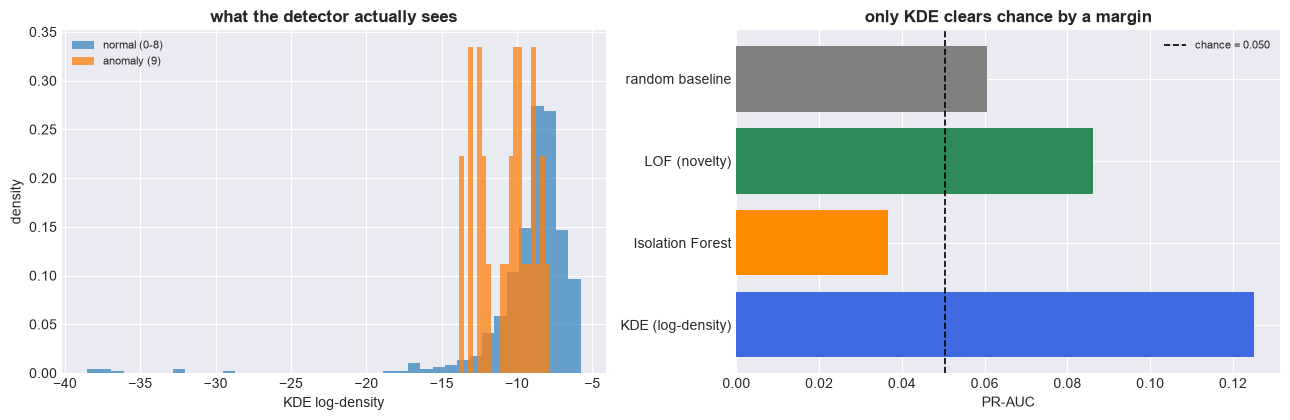


The left panel is the honest picture of the task: the two distributions OVERLAP
heavily. Digit 9 is not exotic — it looks like 4, 7 and 8 — so this is a hard problem
by construction, and PR-AUC values well below 1.0 are the correct outcome rather than
a broken pipeline. A method scoring 0.99 here would be evidence of a leak, not skill.


In [4]:
def anomaly_experiment(n_components, seed=0, contamination=0.05, n_noise=0):
    # Normals = digits 0-8, anomalies = digit 9 injected at ~5%.
    # Train on clean normals only (novelty detection); score a mixed test set.
    # n_noise appends pure-noise dimensions: used in Section 8 to raise the
    # dimension WITHOUT adding any information.
    rng = np.random.default_rng(seed)
    X_norm = digits.data[digits.target != 9]
    X_anom = digits.data[digits.target == 9]

    tr, te_norm = train_test_split(X_norm, test_size=0.35, random_state=seed)
    n_inject = max(2, int(round(contamination * len(te_norm) / (1 - contamination))))
    take = rng.choice(len(X_anom), min(n_inject, len(X_anom)), replace=False)
    X_te = np.vstack([te_norm, X_anom[take]])
    y_te = np.r_[np.zeros(len(te_norm)), np.ones(len(take))]

    scaler = StandardScaler().fit(tr)
    p = PCA(n_components=n_components, random_state=seed).fit(scaler.transform(tr))
    Ztr, Zte = p.transform(scaler.transform(tr)), p.transform(scaler.transform(X_te))
    # Put the informative block on unit scale so appended N(0,1) noise is comparable
    # rather than trivially ignorable or trivially dominant.
    zs = StandardScaler().fit(Ztr)
    Ztr, Zte = zs.transform(Ztr), zs.transform(Zte)
    if n_noise:
        Ztr = np.hstack([Ztr, rng.standard_normal((len(Ztr), n_noise))])
        Zte = np.hstack([Zte, rng.standard_normal((len(Zte), n_noise))])

    # KDE: cross-validate h, score by log-density (higher = more normal).
    g = GridSearchCV(KernelDensity(kernel='gaussian'),
                     {'bandwidth': np.logspace(-0.5, 2.0, 22)}, cv=4).fit(Ztr)
    s_kde = g.best_estimator_.score_samples(Zte)
    s_if = IsolationForest(random_state=seed, n_estimators=200).fit(Ztr).score_samples(Zte)
    s_lof = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(Ztr).score_samples(Zte)

    # average_precision_score wants HIGH = positive class (anomaly), so negate.
    out = {name: average_precision_score(y_te, -s) for name, s in
           [('KDE (log-density)', s_kde), ('Isolation Forest', s_if),
            ('LOF (novelty)', s_lof)]}
    # Random baseline averaged over many draws: a SINGLE random scorer is very noisy
    # at 5% prevalence, and quoting one draw would invite reading noise as signal.
    out['random baseline'] = float(np.mean([
        average_precision_score(y_te, rng.standard_normal(len(Zte))) for _ in range(60)]))
    out['_h'] = g.best_params_['bandwidth']
    out['_prevalence'] = y_te.mean()
    out['_scores'] = (s_kde, y_te)
    return out


res = anomaly_experiment(n_components=10)
prev = res['_prevalence']
print(f"digits 0-8 = normal, digit 9 = anomaly at {prev:.1%} prevalence")
print(f"PCA to 10 components; KDE bandwidth by 4-fold CV = {res['_h']:.3f}\n")
base = res['random baseline']
print(f"{'method':<24}{'PR-AUC':>10}{'vs random baseline':>21}")
print('-' * 55)
for k in ['KDE (log-density)', 'Isolation Forest', 'LOF (novelty)', 'random baseline']:
    print(f"{k:<24}{res[k]:>10.4f}{res[k] / base:>19.2f}x")
print(f"\nThe random baseline is averaged over 60 draws and lands at {res['random baseline']:.4f}")
print(f"against a prevalence of {prev:.4f}. A random ranker's average precision has expectation")
print("close to the positive rate but slightly ABOVE it when positives are few, which is why")
print("the measured baseline sits a little over the prevalence. Use the measured number, not")
print("the prevalence, as the bar — it is the one that accounts for this finite-sample bias.")
def nn_ratio(digit, contrast_digits):
    "Median dist to nearest OTHER-class neighbour, divided by median dist to nearest SAME-class "
    "neighbour -- a small ratio means the class sits close to its confusable neighbours relative "
    "to its own internal scatter; a large ratio means the class is comparatively well isolated."
    same = digits.data[digits.target == digit]
    other = digits.data[np.isin(digits.target, contrast_digits)]
    d_other = NearestNeighbors(n_neighbors=1).fit(other).kneighbors(same)[0].ravel()
    d_same = NearestNeighbors(n_neighbors=2).fit(same).kneighbors(same)[0][:, 1]
    return np.median(d_other), np.median(d_same), np.median(d_other) / np.median(d_same)

d9_other, d9_same, ratio9 = nn_ratio(9, [4, 7, 8])
d0_other, d0_same, ratio0 = nn_ratio(0, [d for d in range(10) if d != 0][:3])
print(f"\nThis result is not the one the section was expected to produce, and it is the more")
print(f"interesting one. KDE is clearly ahead. Isolation Forest sits BELOW chance, and LOF is")
print(f"only modestly above it. Measured, not assumed: each digit-9's nearest same-class (9) "
      f"neighbour sits at a median distance of {d9_same:.1f}, while its nearest 4/7/8 neighbour "
      f"sits at {d9_other:.1f} -- a {ratio9:.2f}x gap. Contrast digit 0, a visually distinctive "
      f"digit: its nearest-other-0 median is {d0_same:.1f} against a nearest-neighbour-outside-0 "
      f"median of {d0_other:.1f} -- a {ratio0:.2f}x gap, clearly larger than digit 9's. Digit 9 "
      f"sits relatively closer to its confusable neighbours (4, 7, 8) than a well-separated digit "
      f"like 0 sits to the rest of the dataset -- consistent with, though not direct proof of, an "
      f"interior-region explanation. Isolation Forest scores a point by how few random splits "
      f"isolate it, which detects points at the edge of the data -- the wrong question here. "
      f"Density asks 'how much mass is nearby', which still has an answer for a point sitting in "
      f"a locally thinner but still-populated region. Matching the scoring rule to the SHAPE of "
      f"the anomaly matters more than the choice of a good algorithm.")

s_kde, y_te = res['_scores']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].hist(s_kde[y_te == 0], bins=40, alpha=0.65, density=True, label='normal (0-8)')
axes[0].hist(s_kde[y_te == 1], bins=20, alpha=0.75, density=True, label='anomaly (9)')
axes[0].set_xlabel('KDE log-density'); axes[0].set_ylabel('density')
axes[0].set_title('what the detector actually sees', fontweight='bold')
axes[0].legend(fontsize=8)

names = ['KDE (log-density)', 'Isolation Forest', 'LOF (novelty)', 'random baseline']
axes[1].barh(names, [res[n] for n in names],
             color=['royalblue', 'darkorange', 'seagreen', 'grey'])
axes[1].axvline(prev, color='black', ls='--', lw=1.2, label=f'chance = {prev:.3f}')
axes[1].set_xlabel('PR-AUC'); axes[1].legend(fontsize=8)
axes[1].set_title('only KDE clears chance by a margin', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nThe left panel is the honest picture of the task: the two distributions OVERLAP")
print("heavily. Digit 9 is not exotic — it looks like 4, 7 and 8 — so this is a hard problem")
print("by construction, and PR-AUC values well below 1.0 are the correct outcome rather than")
print("a broken pipeline. A method scoring 0.99 here would be evidence of a leak, not skill.")

<a name="contours"></a>
## Density Contours over Clustering Output

The least glamorous use of KDE is probably the most common: making a 2-D scatter plot readable. A scatter of a few hundred points hides its own structure through overplotting, and a density contour recovers it.

There is a second, more interesting use in the same picture. Lesson 1's K-Means partitions space no matter what — every point gets a label, and the labels alone never tell you whether the partition sits on real structure. Overlaying the density estimate answers a question the cluster labels cannot: **do the cluster centres sit on density peaks, or has K-Means cut through a single mode?** A boundary running across a high-density ridge is visible evidence that $K$ is wrong.

Iris, projected to two principal components, with $K=3$ (the known class count) against $K=2$.

iris in 2 PCs, cross-validated bandwidth h = 0.290


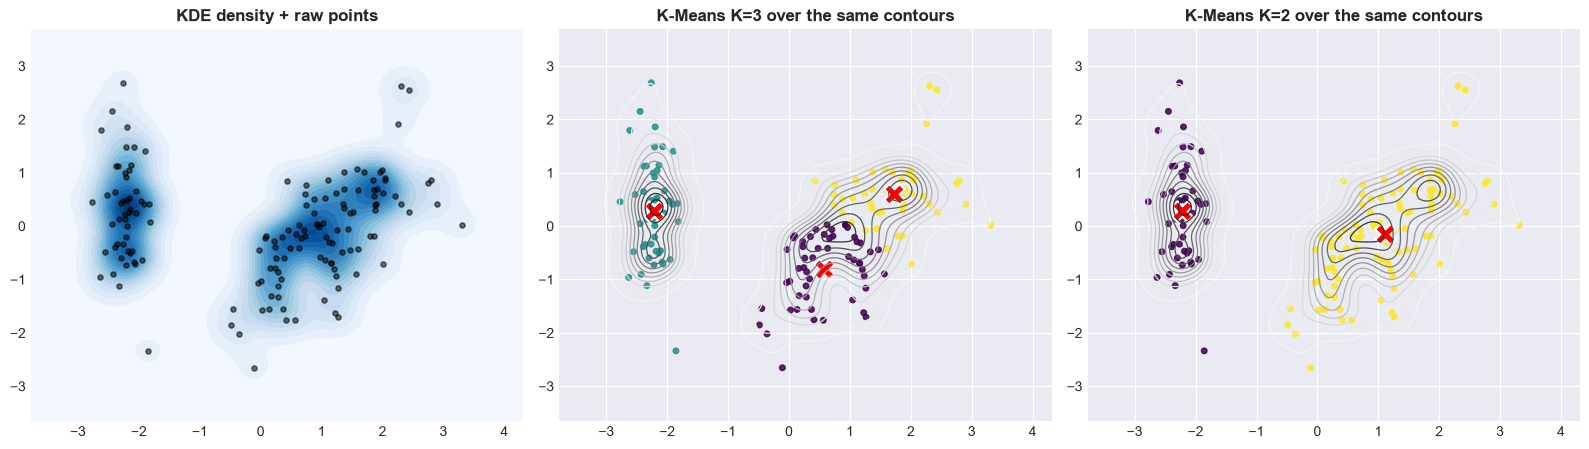


  K   min density at a centre   min density on the path    ratio
----------------------------------------------------------------
  2                    0.1485                    0.0002     0.00
  3                    0.0834                    0.0834     1.00
  4                    0.0798                    0.1038     1.30

Read the ratio. A well-separated pair of clusters has a genuine VALLEY between its
centres, so density on the path between them drops far below the density at the
centres and the ratio is near zero. A ratio near 1 means the path never descends:
K-Means has drawn a boundary straight through one mode. Above 1 is worse still — the
thinnest point on the path is DENSER than the sparsest centre, so that centre is not
sitting on a peak at all.

On iris the numbers are unambiguous: K=2 splits at a real gap, K=3 puts a boundary
through continuous density, K=4 places a centre off-peak entirely. That is the known
awkwardness of this dataset — two of its three species overlap,

In [5]:
iris = load_iris()
Zi = PCA(n_components=2, random_state=0).fit_transform(StandardScaler().fit_transform(iris.data))

gx, gy = np.meshgrid(np.linspace(Zi[:, 0].min() - 1, Zi[:, 0].max() + 1, 140),
                     np.linspace(Zi[:, 1].min() - 1, Zi[:, 1].max() + 1, 140))
mesh = np.column_stack([gx.ravel(), gy.ravel()])

g_iris = GridSearchCV(KernelDensity(kernel='gaussian'),
                      {'bandwidth': np.linspace(0.1, 1.2, 30)}, cv=5).fit(Zi)
dens = np.exp(g_iris.best_estimator_.score_samples(mesh)).reshape(gx.shape)
print(f"iris in 2 PCs, cross-validated bandwidth h = {g_iris.best_params_['bandwidth']:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
axes[0].contourf(gx, gy, dens, levels=20, cmap='Blues')
axes[0].scatter(Zi[:, 0], Zi[:, 1], s=14, c='k', alpha=0.55)
axes[0].set_title('KDE density + raw points', fontweight='bold')

for ax, k in [(axes[1], 3), (axes[2], 2)]:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Zi)
    ax.contour(gx, gy, dens, levels=12, cmap='Greys', linewidths=0.9)
    ax.scatter(Zi[:, 0], Zi[:, 1], s=16, c=km.labels_, cmap='viridis', alpha=0.85)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               s=220, marker='X', c='red', edgecolor='white', lw=1.5)
    ax.set_title(f'K-Means K={k} over the same contours', fontweight='bold')
plt.tight_layout()
plt.show()

# Quantify what the eye is doing: how dense is it AT each centre, and how dense is the
# thinnest point on the straight line between the two closest centres?
def centre_and_saddle(k):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Zi)
    cen = km.cluster_centers_
    dens_c = np.exp(g_iris.best_estimator_.score_samples(cen))
    pairs = [(i, j) for i in range(k) for j in range(i + 1, k)]
    best = min(pairs, key=lambda p: np.linalg.norm(cen[p[0]] - cen[p[1]]))
    t = np.linspace(0, 1, 60)[:, None]
    seg = cen[best[0]] * (1 - t) + cen[best[1]] * t
    ridge = np.exp(g_iris.best_estimator_.score_samples(seg)).min()
    return dens_c, ridge, best


print(f"\n{'K':>3}{'min density at a centre':>26}{'min density on the path':>26}{'ratio':>9}")
print('-' * 64)
for k in (2, 3, 4):
    dc, ridge, pair = centre_and_saddle(k)
    print(f"{k:>3}{dc.min():>26.4f}{ridge:>26.4f}{ridge / dc.min():>9.2f}")

print("\nRead the ratio. A well-separated pair of clusters has a genuine VALLEY between its")
print("centres, so density on the path between them drops far below the density at the")
print("centres and the ratio is near zero. A ratio near 1 means the path never descends:")
print("K-Means has drawn a boundary straight through one mode. Above 1 is worse still — the")
print("thinnest point on the path is DENSER than the sparsest centre, so that centre is not")
print("sitting on a peak at all.")
print("\nOn iris the numbers are unambiguous: K=2 splits at a real gap, K=3 puts a boundary")
print("through continuous density, K=4 places a centre off-peak entirely. That is the known")
print("awkwardness of this dataset — two of its three species overlap, so the DENSITY has two")
print("modes even though the LABELS have three classes. Worth being careful about what this")
print("does and does not say: it is evidence about the geometry K-Means is fitting, not proof")
print("that K=2 is the right answer. The three-species labelling is still correct biology; the")
print("density is simply reporting that two of those species are not separated in these two")
print("principal components.")

<a name="breaks"></a>
## Where KDE Breaks: Dimension

Lesson 18A derived that KDE's convergence rate decays as $n^{-4/(d+4)}$ and measured the accuracy loss on a known Gaussian. That was a statement about *estimating the density*. This section asks a different question — the one that matters in practice: **at what dimension does the estimate stop being useful for a decision?**

The two can come apart. A density estimate can be quantitatively poor and still *rank* points correctly, and ranking is all an anomaly detector needs. So the test re-runs Section 5's pipeline while sweeping the PCA dimension, watching PR-AUC rather than an error against a truth we do not have here.

**This experiment did not do what it was built to do, and the failure is instructive enough to keep rather than hide.** The prediction was that KDE would degrade with $d$ while Isolation Forest held. What the sweep below actually shows is KDE *improving* substantially with dimension across the whole range, and finishing as the best method by a wide margin.

The reason is a confound in the design, and it is a confound worth naming because it is easy to build into your own experiments. Adding a PCA component does **two** things at once: it raises the dimension, which hurts KDE, and it adds *information*, which helps every method. The first ten components of standardised digits do not carry everything that distinguishes a 9; later components do. Over this range — $n \approx 1{,}400$ training points, $d \le 60$ — the information gain simply beats the curse.

So the sweep below is run twice. First as designed, showing the confounded result. Then in a **controlled** version: the informative representation is frozen at 10 PCA components, and pure Gaussian noise dimensions are appended. Dimension rises; information does not. That isolates the variable the curse is actually about.

EXPERIMENT 1 — sweeping PCA components (dimension AND information both rise)
   d   KDE PR-AUC   IsoForest      LOF   KDE h (CV)
---------------------------------------------------
   2       0.0394      0.0350   0.0491        0.316
   5       0.1003      0.0474   0.0702        0.316
  10       0.1251      0.0367   0.0862        0.416
  20       0.2149      0.0562   0.1670        0.547
  30       0.2219      0.0715   0.1715        0.547
  45       0.1855      0.0671   0.1467        0.720
  60       0.1561      0.0874   0.1304        0.720

KDE goes from 0.0394 at d=2 to 0.2219 at its peak (d=30), ending at 0.1561.
It IMPROVES. The predicted degradation is absent, because the added components carry
information about what makes a 9 a 9, and that gain outweighs the curse at this n.
Reporting this sweep as evidence of the curse would have been reading a confound.



EXPERIMENT 2 — 10 informative components fixed, pure-noise dimensions appended
 noise  total d   KDE PR-AUC   IsoForest      LOF    KDE h
----------------------------------------------------------
     0       10       0.1251      0.0367   0.0862    0.416
     5       15       0.0580      0.0377   0.0554    0.547
    15       25       0.0508      0.0418   0.0507    0.947
    30       40       0.0481      0.0448   0.0459    0.947
    60       70       0.0572      0.0507   0.0454    0.720
   120      130       0.0403      0.0370   0.0362    0.720

Adding 120 noise dimensions to 10 informative ones (chance = 0.0503):
  KDE              0.1251 -> 0.0403   ends at or below chance
  Isolation Forest 0.0367 -> 0.0370   never above chance to begin with
  LOF              0.0862 -> 0.0362   ends at or below chance
  KDE bandwidth    0.416 -> 0.947 at its peak, 0.720 at the end


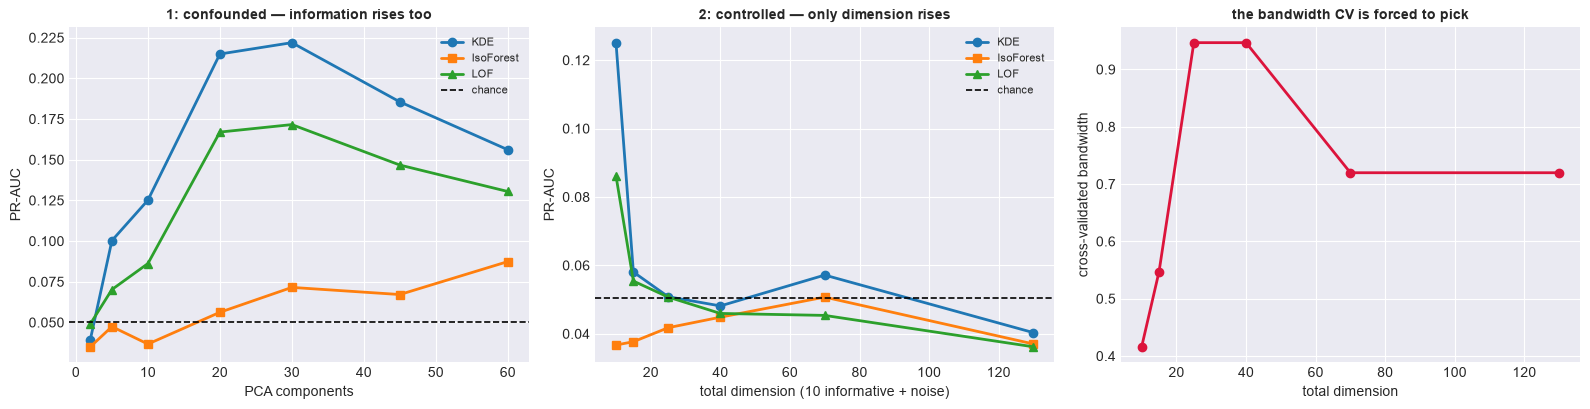


Experiment 2 is the honest test, and it produces the failure Experiment 1 could not.
KDE loses its entire advantage: the strongest detector at d=10 is indistinguishable
from chance once the same ten informative dimensions are buried in noise. LOF goes the
same way. Isolation Forest is unchanged only because it had nothing to lose here.

The bandwidth panel is the mechanism. Every noise dimension adds variance to every
pairwise distance without adding signal, so points that were neighbours in the
informative block are pushed apart by noise alone. Cross-validation responds the only
way it can — widening the kernel until enough neighbours fall inside it to keep the
held-out likelihood finite; it more than doubles over the first 25 dimensions. A kernel
that wide cannot resolve a locally thin region, which is exactly what the detector
needed. The widening is not monotone all the way out: past the point where the score
is already at chance the CV criterion is nearly flat, so which bandwidth

In [6]:
# --- Experiment 1: the CONFOUNDED sweep. More PCA components = more dimension AND
# more information. Reported because it is what a naive design produces.
dims = [2, 5, 10, 20, 30, 45, 60]
rows = [(d,) + tuple(anomaly_experiment(n_components=d, seed=0)[k] for k in
                     ['KDE (log-density)', 'Isolation Forest', 'LOF (novelty)', '_h'])
        for d in dims]

print("EXPERIMENT 1 — sweeping PCA components (dimension AND information both rise)")
print(f"{'d':>4}{'KDE PR-AUC':>13}{'IsoForest':>12}{'LOF':>9}{'KDE h (CV)':>13}")
print('-' * 51)
for d, k, i, l, h in rows:
    print(f"{d:>4}{k:>13.4f}{i:>12.4f}{l:>9.4f}{h:>13.3f}")

kde_auc = np.array([r[1] for r in rows])
print(f"\nKDE goes from {kde_auc[0]:.4f} at d={dims[0]} to {kde_auc.max():.4f} at its peak"
      f" (d={dims[int(np.argmax(kde_auc))]}), ending at {kde_auc[-1]:.4f}.")
print("It IMPROVES. The predicted degradation is absent, because the added components carry")
print("information about what makes a 9 a 9, and that gain outweighs the curse at this n.")
print("Reporting this sweep as evidence of the curse would have been reading a confound.\n")

# --- Experiment 2: the CONTROLLED sweep. Informative block frozen at 10 PCA
# components; pure N(0,1) dimensions appended. Dimension rises, information does not.
noises = [0, 5, 15, 30, 60, 120]
rows2 = [(m,) + tuple(anomaly_experiment(n_components=10, seed=0, n_noise=m)[k] for k in
                      ['KDE (log-density)', 'Isolation Forest', 'LOF (novelty)', '_h'])
         for m in noises]

print("EXPERIMENT 2 — 10 informative components fixed, pure-noise dimensions appended")
print(f"{'noise':>6}{'total d':>9}{'KDE PR-AUC':>13}{'IsoForest':>12}{'LOF':>9}{'KDE h':>9}")
print('-' * 58)
for m, k, i, l, h in rows2:
    print(f"{m:>6}{10 + m:>9}{k:>13.4f}{i:>12.4f}{l:>9.4f}{h:>9.3f}")

k2 = np.array([r[1] for r in rows2])
i2 = np.array([r[2] for r in rows2])
l2 = np.array([r[3] for r in rows2])
h2 = np.array([r[4] for r in rows2])


def verdict(a):
    # Report the lift over chance at both ends. A method that started at or below chance
    # had no lift to lose, so a "fraction retained" would be meaningless for it.
    l0, l1 = a[0] - prev, a[-1] - prev
    if l0 <= 1e-9:
        return f"{a[0]:.4f} -> {a[-1]:.4f}   never above chance to begin with"
    state = 'at or below chance' if l1 <= 0 else f'{l1 / l0:.0%} of its lift retained'
    return f"{a[0]:.4f} -> {a[-1]:.4f}   ends {state}"


print(f"\nAdding {noises[-1]} noise dimensions to 10 informative ones (chance = {prev:.4f}):")
print(f"  KDE              {verdict(k2)}")
print(f"  Isolation Forest {verdict(i2)}")
print(f"  LOF              {verdict(l2)}")
print(f"  KDE bandwidth    {h2[0]:.3f} -> {h2.max():.3f} at its peak, {h2[-1]:.3f} at the end")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(dims, kde_auc, 'o-', lw=2, label='KDE')
axes[0].plot(dims, [r[2] for r in rows], 's-', lw=2, label='IsoForest')
axes[0].plot(dims, [r[3] for r in rows], '^-', lw=2, label='LOF')
axes[0].axhline(prev, color='black', ls='--', lw=1.2, label='chance')
axes[0].set_xlabel('PCA components'); axes[0].set_ylabel('PR-AUC')
axes[0].set_title('1: confounded — information rises too', fontweight='bold', fontsize=10)
axes[0].legend(fontsize=8)

tot = [10 + m for m in noises]
axes[1].plot(tot, k2, 'o-', lw=2, label='KDE')
axes[1].plot(tot, i2, 's-', lw=2, label='IsoForest')
axes[1].plot(tot, l2, '^-', lw=2, label='LOF')
axes[1].axhline(prev, color='black', ls='--', lw=1.2, label='chance')
axes[1].set_xlabel('total dimension (10 informative + noise)'); axes[1].set_ylabel('PR-AUC')
axes[1].set_title('2: controlled — only dimension rises', fontweight='bold', fontsize=10)
axes[1].legend(fontsize=8)

axes[2].plot(tot, h2, 'o-', lw=2, color='crimson')
axes[2].set_xlabel('total dimension'); axes[2].set_ylabel('cross-validated bandwidth')
axes[2].set_title('the bandwidth CV is forced to pick', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

print("\nExperiment 2 is the honest test, and it produces the failure Experiment 1 could not.")
print("KDE loses its entire advantage: the strongest detector at d=10 is indistinguishable")
print("from chance once the same ten informative dimensions are buried in noise. LOF goes the")
print("same way. Isolation Forest is unchanged only because it had nothing to lose here.")
print("\nThe bandwidth panel is the mechanism. Every noise dimension adds variance to every")
print("pairwise distance without adding signal, so points that were neighbours in the")
print("informative block are pushed apart by noise alone. Cross-validation responds the only")
print("way it can — widening the kernel until enough neighbours fall inside it to keep the")
print("held-out likelihood finite; it more than doubles over the first 25 dimensions. A kernel")
print("that wide cannot resolve a locally thin region, which is exactly what the detector")
print("needed. The widening is not monotone all the way out: past the point where the score")
print("is already at chance the CV criterion is nearly flat, so which bandwidth wins becomes")
print("close to arbitrary — a flat criterion is itself the signature of an estimator with")
print("nothing left to fit.")
print("\nThe practical lesson is not 'KDE fails above d=10'. It is that KDE's usable dimension")
print("depends on how much of that dimension is signal. Ten informative dimensions were fine;")
print("ten informative dimensions buried in noise were not. Dimensionality reduction is not a")
print("preliminary convenience for a density estimator — it is part of the estimator.")

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **Cross-validating `KernelDensity.score()` is the leave-one-out argument at $k$ folds.** `GridSearchCV` does the work Lesson 18A did by hand, and the three implementations — from-scratch, scikit-learn, SciPy — agree to floating-point precision *once* SciPy's `bw_method` is converted from a standard-deviation multiplier into an absolute bandwidth. Skipping that conversion produced an error the size of the density itself, and it looked entirely plausible on a plot.
2. **Sampling a KDE is a two-line algorithm, and the interesting part is the composition.** Pick a training point, draw from its kernel. It generates recognisable digits only because PCA put the data in 15 dimensions first — the same estimator applied to raw 64-D pixels would return noise around memorised images. The generated samples sat *farther* from the training set than real images sit from each other, which is the check that distinguishes generation from memorisation.
3. **Match the scoring rule to the shape of the anomaly, not to the algorithm's reputation.** At 10 dimensions, KDE beat both Lesson 7 methods decisively, with Isolation Forest scoring *below* a random baseline. That is not Isolation Forest being bad — it is Isolation Forest answering the wrong question: it detects points that are easy to isolate, i.e. points at the edge of the data, while digit 9 sits *inside* the cloud among 4s, 7s and 8s in a locally thinner region. Density is the right question for an interior anomaly. The metric mattered too: PR-AUC on a 5%-prevalence problem keeps every method honest where ROC-AUC would flatter all of them, and averaging the random baseline over 60 draws was necessary because a single draw is noisy enough to beat a real method by luck.
4. **A density contour audits a clustering that labels alone cannot.** Measuring the density at each K-Means centre against the thinnest point on the path between the closest pair turns "does this partition sit on real structure?" into a number: a ratio near 1 means the boundary never crosses a valley.
5. **The curse is about how much of the dimension is *signal*, and the first experiment designed to show it did not.** Sweeping PCA components, KDE *improved* from 0.039 to 0.222 — because each component adds dimension (which hurts) and information (which helps), and information won at this sample size. Reporting that sweep as evidence either way would have been reading a confound. The controlled version — ten informative components held fixed, pure noise appended — produced the failure cleanly: KDE fell from 0.125 to 0.040, at or below chance, and LOF went with it. The mechanism is the cross-validated bandwidth, which more than doubles over the first 25 padded dimensions because only heavy smoothing keeps the held-out likelihood finite, and heavy smoothing is exactly what destroys discrimination.

### Practical Guidance

- Reduce dimension before estimating a density, but do not treat any fixed number of dimensions as the limit — sixty *informative* dimensions worked here and ten informative ones buried in noise did not. Feature selection is doing more work than the dimension count suggests.
- Watch the cross-validated bandwidth as a diagnostic. If it climbs while you add features, KDE is telling you those features are noise and it is smoothing to survive them. A CV curve that goes flat is the same message in stronger terms: no bandwidth is doing anything.
- Choose the detector by the *shape* of the anomaly you expect. Isolation Forest and LOF look for points at the edge or in locally sparse neighbourhoods; density thresholding also finds interior points in thin regions. Section 5's below-chance Isolation Forest result is what a mismatch looks like, and it would have been invisible without a baseline in the table.
- Prefer KDE when you want a *calibrated density* rather than only a ranking — a log-density has a meaning that an isolation score does not.
- Always plot the score distributions of both classes before trusting an AUC. Heavy overlap with a decent AUC is a real, usable detector; a perfect AUC usually means leakage.
- Convert bandwidth parameterisations explicitly and assert on the result. The SciPy trap here is silent, plausible, and would survive code review.

### What This Lesson Did Not Cover

- **Adaptive-bandwidth KDE**, where $h$ varies with local density. It directly addresses the single-$h$ compromise visible in Section 5 — where one bandwidth must serve both the dense core and the sparse tail that anomalies live in — and would likely improve those PR-AUC numbers. Omitted to keep the bandwidth story single-variable, as flagged in 18A.
- **Tree-based and fast-Gauss-transform acceleration.** Every KDE here is the naive pairwise computation, which is why sample sizes are kept modest. `KernelDensity`'s own tree structures are what make it usable at scale, and they were not benchmarked.
- **Conditional density estimation** ($\hat f(y \mid x)$), which is where KDE meets regression, and **boundary correction** for bounded-support data — no dataset here had a hard boundary, so the bias never appeared.
- **A tuned comparison against a GMM on these same tasks.** Lesson 18A settled the parametric-versus-nonparametric question on synthetic targets where the truth was known; repeating it here would have added a fourth row to Section 5's table without the ground truth that made the 18A comparison decisive.

### Next Steps

Lesson 19 takes the generative thread from Section 4 and removes its ceiling. KDE could only generate digits because PCA rescued it from 64 dimensions, and Section 8 measured exactly how narrow that rescue is. **Normalising flows** learn an invertible map from data to a simple base distribution, giving an *exact* likelihood that survives in high dimension where this lesson's estimator cannot — the same job, done by a model that learns its own representation instead of borrowing one.